# Train Decision Tree Model

## Motivation
A **Decision Tree** was chosen for this alarm-prediction task for three reasons:

1. **Non-linearity** — alarm patterns are driven by complex threshold combinations (e.g. `alarm_status_1h_ago == 1 AND alarms_count_1h_ago > 5`). Linear models struggle to capture these; a tree splits on exactly such boundaries natively.
2. **Mixed feature types** — the dataset has numeric weather/NLP features alongside binary categorical flags. Decision Trees handle both without requiring standardisation, making the pipeline simpler and easier to interpret.
3. **Interpretability & feature importance** — trees provide native `feature_importances_` (Gini impurity reduction), giving a direct and meaningful ranking of features with no extra computation. This is a key task requirement.

In [1]:
import os
os.chdir("..")

In [2]:
import datetime as dt
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from time import time

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    f1_score, average_precision_score, matthews_corrcoef,
    confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [15]:
def calculate_transition_weights(X, y):
    is_change = X['alarm_status_1h_ago'].values != y.values
    n_same = (~is_change).sum()
    n_change = is_change.sum()
    weight_change = n_same / n_change
    sample_weights = np.where(is_change, weight_change, 1.0)
    return sample_weights

def combined_weights(X, y):
    transition_weights = calculate_transition_weights(X, y)
    n_neg = (y == 0).sum()
    n_pos = (y == 1).sum()
    class_w = np.where(y == 1, n_neg / n_pos, 1.0)
    sample_weights = transition_weights * class_w
    return sample_weights

# Loading data

In [16]:
data_path = Path("data/merged_preprocessed.csv")

data = pd.read_csv(data_path)
data["time"] = pd.to_datetime(data["time"], utc=True).dt.tz_convert("Europe/Kyiv")
data = data.sort_values(by=["region_id", "time"])

data = data.drop(columns=["year", "month", "day"], errors="ignore")

data = data.loc[data.time < '2026-04-08']

target = "alarm"

X = data.copy()
y = X.pop(target)

print(f"Dataset shape : {data.shape}")
print(f"Percent alarms: {y.mean():.2%}")

Dataset shape : (821904, 114)
Percent alarms: 20.47%


In [17]:
data.info()

<class 'pandas.DataFrame'>
Index: 821904 entries, 0 to 823421
Columns: 114 entries, region_id to is_weekend
dtypes: datetime64[us, Europe/Kyiv](1), float64(72), int64(41)
memory usage: 721.1 MB


In [18]:
data.head()

,region_id,time,alarm,temp,feelslike,humidity,dew,precip,precipprob,preciptype,windspeed,winddir,pressure,visibility,cloudcover,uvindex,conditions,messages_count,has_threat_sum,nlp_артобстрілу,nlp_бпла,nlp_відбій,nlp_відбій_тривоги,nlp_дніпропетровська,nlp_донецька,nlp_запорізька,nlp_нікополь,nlp_нікополь_нікопольська,nlp_нікопольська,nlp_повітряна,nlp_повітряна_тривога,nlp_тривога,nlp_тривоги,nlp_харківська,msg_count_last_3h,msg_count_last_24h,threat_diff_1h,text_length,isw_cluster_0,isw_cluster_1,isw_cluster_2,isw_cluster_3,isw_cluster_4,isw_cluster_5,isw_cluster_6,isw_cluster_7,isw_cluster_8,isw_cluster_9,news_count_7d,news_velocity_30d,dom_cluster_share_7d,dom_cluster_share_30d,centroid_shift_30d,news_velocity_7d,avg_dist_centroid_30d,centroid_shift_7d,anomaly_count_30d,news_count_30d,topic_entropy_30d,avg_dist_centroid_7d,topic_entropy_7d,anomaly_count_7d,alarms_count_1h_ago,alarms_count_2h_ago,alarms_count_3h_ago,alarms_count_4h_ago,alarms_count_5h_ago,alarms_count_6h_ago,alarms_count_7h_ago,alarms_count_8h_ago,alarms_count_9h_ago,alarms_count_10h_ago,alarms_count_11h_ago,alarms_count_12h_ago,alarms_count_13h_ago,alarms_count_14h_ago,alarms_count_15h_ago,alarms_count_16h_ago,alarms_count_17h_ago,alarms_count_18h_ago,alarms_count_19h_ago,alarms_count_20h_ago,alarms_count_21h_ago,alarms_count_22h_ago,alarms_count_23h_ago,alarms_count_24h_ago,alarm_status_1h_ago,alarm_status_2h_ago,alarm_status_3h_ago,alarm_status_4h_ago,alarm_status_5h_ago,alarm_status_6h_ago,alarm_status_7h_ago,alarm_status_8h_ago,alarm_status_9h_ago,alarm_status_10h_ago,alarm_status_11h_ago,alarm_status_12h_ago,alarm_status_13h_ago,alarm_status_14h_ago,alarm_status_15h_ago,alarm_status_16h_ago,alarm_status_17h_ago,alarm_status_18h_ago,alarm_status_19h_ago,alarm_status_20h_ago,alarm_status_21h_ago,alarm_status_22h_ago,alarm_status_23h_ago,alarm_status_24h_ago,neighbor_alarm_count,hour,day_of_week,is_weekend
0,3,2022-03-27 00:00:00+02:00,0,7.0,3.1,68.99,1.7,0.0,0.0,0.0,24.5,312.8,1018.0,24.1,55.8,0.0,4.0,19,7,0,0,7,7,2,0,0,0,0,0,6,6,7,7,4,42,352,5,11717,0,0,0,0,0,0,0,0,0,1,10,48,0.7,0.620000,0.533511,2,0.471807,0.173424,5,50,0.664064,0.388121,0.610864,1,3.0,1.0,8.0,7.0,13.0,22.0,22.0,22.0,13.0,13.0,11.0,1.0,2.0,1.0,1.0,1.0,1.0,10.0,8.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6,1
1,3,2022-03-27 01:00:00+02:00,0,5.7,1.2,44.72,-5.4,0.0,0.0,0.0,26.6,326.8,1019.0,24.1,4.2,0.0,0.0,12,8,0,0,0,0,2,0,2,0,0,0,8,8,8,0,2,37,360,1,11717,0,0,0,0,0,0,0,0,0,1,10,48,0.7,0.620000,0.533511,2,0.471807,0.173424,5,50,0.664064,0.388121,0.610864,1,5.0,3.0,1.0,8.0,7.0,13.0,22.0,22.0,22.0,13.0,13.0,11.0,1.0,2.0,1.0,1.0,1.0,1.0,10.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6,1
2,3,2022-03-27 02:00:00+02:00,0,3.8,-0.9,43.48,-7.5,0.0,0.0,0.0,23.8,322.6,1021.0,24.1,0.0,0.0,0.0,23,10,0,0,11,11,2,0,2,0,0,0,10,10,12,11,2,54,378,2,11717,0,0,0,0,0,0,0,0,0,1,10,48,0.7,0.620000,0.533511,2,0.471807,0.173424,5,50,0.664064,0.388121,0.610864,1,13.0,5.0,3.0,1.0,8.0,7.0,13.0,22.0,22.0,22.0,13.0,13.0,11.0,1.0,2.0,1.0,1.0,1.0,1.0,10.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2.0,6,1
3,3,2022-03-28 04:00:00+03:00,0,-1.3,-1.3,56.25,-8.9,0.0,0.0,0.0,4.3,228.8,1029.0,24.1,18.8,0.0,0.0,11,10,0,0,0,0,2,0,2,0,0,0,9,9,9,0,2,26,275,10,13953,0,0,0,0,0,0,0,0,0,1,10,45,0.7,0.632653,0.484262,2,0.465249,0.179787,5,49,0.657529,0.386532,0.610864,1,8.0,2.0,4.0,5.0,10.0,24.0,15.0,3.0,0.0,0.0,3.0,3.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,3.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,0,0
4,3,2022-03-28 05:00:00+03:00,0,-1.3,-1.3,56.69,-8.8,0.0,0.0,0.0,3.6,199.3,1029.0,24.1,87.8,0.0,4.0,9,1,0,0,6,6,2,0,2,0,0,0,1,1,2,6,2,27,283,-9,13953,0,0,0,0,0,0,0,0,0,1,10,45,0.7,0.632653,0.484262,2,0.465249,0.179787,5,49,0.657529,

# Feature groups

Decision Trees are **invariant to feature scaling** — splits are rank-based, not magnitude-based.  
Therefore no `StandardScaler` is used. Categorical columns are label-encoded integers and pass through as-is.

In [19]:
NON_FEATURES = {"time", "region_id"}

# Auto-detect feature types
cat_cols = [
    c for c in X.select_dtypes(include=["category", "object"], exclude=["datetime"]).columns
    if c not in NON_FEATURES
]
num_cols = [
    c for c in X.select_dtypes(include="number").columns
    if c not in cat_cols and c not in NON_FEATURES
]

feature_cols = num_cols + cat_cols

print(f"Numeric     : {len(num_cols)}")
print(f"Categorical : {len(cat_cols)}")
print(f"Total       : {len(feature_cols)}")

Numeric     : 111
Categorical : 0
Total       : 111


# Model pipeline

No preprocessing needed for a Decision Tree — all features pass through directly.

In [20]:
model = Pipeline([
    ("classifier", DecisionTreeClassifier(
        max_depth=10,
        min_samples_leaf=50,
        random_state=42
    ))
])

# Cross-validation with `evaluate_model`

Uses global `TimeSeriesSplit` — splits on timestamps across all regions simultaneously.

**Metrics explained:**

| Metric | Meaning |
|--------|---------|
| **Train F1** | F1 on training folds — should be higher than Test F1 but not 1.000 (that means overfitting) |
| **Test F1** | F1 on held-out future data — the key generalisation metric |
| **AUPRC** | Area Under Precision-Recall Curve — best metric for imbalanced data; not inflated by the large TN count unlike ROC-AUC |
| **MCC** | Matthews Correlation Coefficient — balanced metric even for imbalanced classes; 0 = random, 1 = perfect |

**Confusion matrix cells:**

| Cell | Meaning | Cost |
|------|---------|------|
| **TN** | Correctly predicted no alarm | Low |
| **FP** | Predicted alarm, no alarm occurred | Medium (unnecessary alert) |
| **FN** | Predicted no alarm, alarm occurred | **High** (missed threat) |
| **TP** | Correctly predicted alarm | None |

In [21]:
def evaluate_model(pipeline, X=X, y=y, n_splits: int = 5, gap: int = 24, max_train_size=None, weights_func=None):
    train_scores = []
    test_scores  = []
    auprc_scores = []
    mcc_scores   = []

    all_y_true = []
    all_y_pred = []

    training_start = time()

    unique_hours = X["time"].sort_values().unique()
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap, max_train_size=max_train_size)

    for fold, (train_idx, test_idx) in enumerate(tscv.split(unique_hours)):
        train_hours = unique_hours[train_idx]
        test_hours  = unique_hours[test_idx]

        train_mask = X["time"].isin(train_hours)
        test_mask  = X["time"].isin(test_hours)

        drop_cols = ["time", "region_id"]
        X_train = X[train_mask].drop(columns=drop_cols)
        X_test  = X[test_mask].drop(columns=drop_cols)
        y_train = y[train_mask]
        y_test  = y[test_mask]

        if len(X_test) == 0:
            print(f"  [warning] Empty test set — fold {fold + 1}")
            continue

        sample_weights = weights_func(X_train, y_train) if weights_func else None
        pipeline.fit(X_train, y_train, classifier__sample_weight=sample_weights)

        y_pred_train    = pipeline.predict(X_train)
        y_pred_test     = pipeline.predict(X_test)
        pred_test_proba = pipeline.predict_proba(X_test)[:, 1]

        train_scores.append(f1_score(y_train, y_pred_train, zero_division=0))
        test_scores.append( f1_score(y_test,  y_pred_test,  zero_division=0))
        auprc_scores.append(average_precision_score(y_test, pred_test_proba))
        mcc_scores.append(  matthews_corrcoef(y_test, y_pred_test))

        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred_test)

        print(f"  Fold {fold+1}  "
              f"Train F1: {train_scores[-1]:.3f}  "
              f"Test F1: {test_scores[-1]:.3f}  "
              f"AUPRC: {auprc_scores[-1]:.3f}  "
              f"MCC: {mcc_scores[-1]:.3f}")

    print("\n-------- Overall --------")
    print(f"Train F1 : {np.mean(train_scores):.3f} \u00b1 {np.std(train_scores):.3f}")
    print(f"Test  F1 : {np.mean(test_scores):.3f} \u00b1 {np.std(test_scores):.3f}")
    print(f"AUPRC    : {np.mean(auprc_scores):.3f} \u00b1 {np.std(auprc_scores):.3f}")
    print(f"MCC      : {np.mean(mcc_scores):.3f} \u00b1 {np.std(mcc_scores):.3f}")
    print(f"Completed in: {time() - training_start:.2f}s")

    scores = {
        "train_f1": train_scores,
        "test_f1":  test_scores,
        "auprc":    auprc_scores,
        "mcc":      mcc_scores,
    }
    overall_cm = confusion_matrix(all_y_true, all_y_pred)
    return scores, overall_cm

## Baseline evaluation (before tuning)

In [22]:
print("-------- Per-Fold Results --------")
scores, cm = evaluate_model(model)

-------- Per-Fold Results --------
  Fold 1  Train F1: 0.645  Test F1: 0.632  AUPRC: 0.681  MCC: 0.617
  Fold 2  Train F1: 0.655  Test F1: 0.628  AUPRC: 0.721  MCC: 0.580
  Fold 3  Train F1: 0.659  Test F1: 0.687  AUPRC: 0.798  MCC: 0.617
  Fold 4  Train F1: 0.686  Test F1: 0.757  AUPRC: 0.853  MCC: 0.695
  Fold 5  Train F1: 0.710  Test F1: 0.733  AUPRC: 0.834  MCC: 0.661

-------- Overall --------
Train F1 : 0.671 ± 0.024
Test  F1 : 0.687 ± 0.052
AUPRC    : 0.777 ± 0.066
MCC      : 0.634 ± 0.040
Completed in: 32.03s


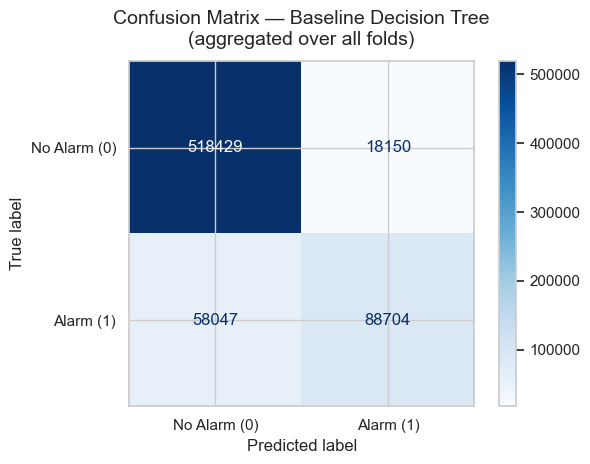

In [23]:
disp = ConfusionMatrixDisplay(
    cm,
    display_labels=["No Alarm (0)", "Alarm (1)"]
)
disp.plot(cmap="Blues")
plt.title(
    "Confusion Matrix - Baseline Decision Tree",
    fontsize=14, pad=12
)
plt.tight_layout()
plt.show()

# Hyperparameter Tuning - GridSearchCV

## Scoring metrics

| Metric | Why used                                                                                                                                               |
|--------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| **`f1`** | Primary metric - balances Precision and Recall for the 20/80 imbalanced split                                                                          |
| **`average_precision`** | Best complement for imbalanced binary classification - AUPRC summarises P-R trade-off across all thresholds without being skewed by the large TN count |

**Refit:** `f1` - consistent with `evaluate_model` across all models in this project.

In [ ]:
tscv_gs = TimeSeriesSplit(n_splits=3, gap=24)

param_grid = {
    "classifier__criterion":         ["gini", "entropy"],
    "classifier__max_depth":         [5, 10, 20],
    "classifier__min_samples_split": [20, 100],
    "classifier__min_samples_leaf":  [20, 50, 100],
    "classifier__max_features":      [None, "sqrt"],
    "classifier__class_weight":      ["balanced"],
}
# 2x3x2x3x2x1 = 72 combinations x 3 folds = 216 fits

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring={"f1": "f1", "average_precision": "average_precision"},
    refit="f1",
    cv=tscv_gs,
    n_jobs=-1,
    verbose=2,
    return_train_score=True,
)

# Full dataset, no sampling
X_gs = X.drop(columns=["time", "region_id"])

t0 = time()
grid_search.fit(X_gs, y)
print(f"\nGridSearchCV completed in: {time() - t0:.2f}s")

Fitting 3 folds for each of 72 candidates, totalling 216 fits
[CV] END classifier__class_weight=balanced, classifier__criterion=gini, classifier__max_depth=5, classifier__max_features=None, classifier__min_samples_leaf=20, classifier__min_samples_split=100; total time=  15.1s
[CV] END classifier__class_weight=balanced, classifier__criterion=gini, classifier__max_depth=5, classifier__max_features=sqrt, classifier__min_samples_leaf=20, classifier__min_samples_split=20; total time=   0.7s
[CV] END classifier__class_weight=balanced, classifier__criterion=gini, classifier__max_depth=5, classifier__max_features=sqrt, classifier__min_samples_leaf=20, classifier__min_samples_split=20; total time=   2.1s
[CV] END classifier__class_weight=balanced, classifier__criterion=gini, classifier__max_depth=5, classifier__max_features=None, classifier__min_samples_leaf=20, classifier__min_samples_split=100; total time=   9.7s
[CV] END classifier__class_weight=balanced, classifier__criterion=gini, classifi

In [ ]:
print("Best parameters:")
for param, val in grid_search.best_params_.items():
    print(f"  {param.replace('classifier__', '')}: {val}")

best_idx = grid_search.best_index_
print(f"\nBest CV F1    : {grid_search.best_score_:.4f}")
print(f"Best CV AUPRC : {grid_search.cv_results_['mean_test_average_precision'][best_idx]:.4f}")

Best parameters:
  class_weight: balanced
  criterion: entropy
  max_depth: 10
  max_features: None
  min_samples_leaf: 20
  min_samples_split: 20

Best CV F1    : 0.6839
Best CV AUPRC : 0.7980


In [ ]:
cv_results = pd.DataFrame(grid_search.cv_results_)

top10 = (
    cv_results
    .sort_values("mean_test_f1", ascending=False)
    .head(10)
    [[
        "param_classifier__criterion",
        "param_classifier__max_depth",
        "param_classifier__min_samples_split",
        "param_classifier__min_samples_leaf",
        "param_classifier__max_features",
        "mean_test_f1",
        "mean_test_average_precision",
    ]]
    .rename(columns=lambda c: c.replace("param_classifier__", "").replace("mean_test_", ""))
    .reset_index(drop=True)
)

top10

,criterion,max_depth,min_samples_split,min_samples_leaf,max_features,f1,average_precision
0,entropy,10,20,20,NaN,0.683855,0.797988
1,entropy,10,100,20,NaN,0.683549,0.799748
2,entropy,10,100,50,NaN,0.682581,0.800111
3,entropy,10,20,50,NaN,0.682581,0.800111
4,entropy,5,20,20,NaN,0.680443,0.768863
5,entropy,5,100,20,NaN,0.680443,0.768863
6,entropy,5,20,50,NaN,0.680443,0.768853
7,entropy,5,100,50,NaN,0.680443,0.768853
8,entropy,5,20,100,NaN,0.680443,0.768872
9,entropy,5,100,100,NaN,0.680443,0.768872


# Tuned model - full evaluation

Auto-selects the better model (GridSearch vs baseline) by Test F1.

In [27]:
gs_best = grid_search.best_estimator_

print("-------- Per-Fold Results (GridSearch best) --------")
scores_tuned, cm_tuned = evaluate_model(gs_best)

# Pick the better model by Test F1
if np.mean(scores_tuned["test_f1"]) >= np.mean(scores["test_f1"]):
    tuned_model = gs_best
    final_cm    = cm_tuned
    print("\n[+] GridSearch model selected (better Test F1)")
else:
    tuned_model = model
    final_cm    = cm
    print("\n[!] Baseline model selected (GridSearch did not improve Test F1)")
    print("    Reason: max_features restriction hurt single-tree performance.")

-------- Per-Fold Results (GridSearch best) --------
  Fold 1  Train F1: 0.617  Test F1: 0.539  AUPRC: 0.653  MCC: 0.468
  Fold 2  Train F1: 0.585  Test F1: 0.583  AUPRC: 0.707  MCC: 0.487
  Fold 3  Train F1: 0.605  Test F1: 0.640  AUPRC: 0.786  MCC: 0.514
  Fold 4  Train F1: 0.653  Test F1: 0.703  AUPRC: 0.854  MCC: 0.600
  Fold 5  Train F1: 0.677  Test F1: 0.753  AUPRC: 0.851  MCC: 0.651

-------- Overall --------
Train F1 : 0.627 ± 0.033
Test  F1 : 0.643 ± 0.077
AUPRC    : 0.770 ± 0.079
MCC      : 0.544 ± 0.070
Completed in: 35.07s

[!] Baseline model selected (GridSearch did not improve Test F1)
    Reason: max_features restriction hurt single-tree performance.


## Confusion Matrix - Final Decision Tree

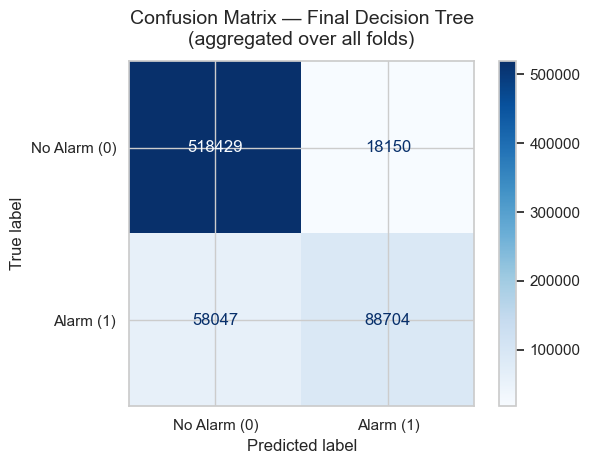

In [28]:
disp_final = ConfusionMatrixDisplay(
    final_cm,
    display_labels=["No Alarm (0)", "Alarm (1)"]
)
disp_final.plot(cmap="Blues")
plt.title(
    "Confusion Matrix - Final Decision Tree\n(aggregated over all folds)",
    fontsize=14, pad=12
)
plt.tight_layout()
plt.show()

# Save model as pickle

In [32]:
# Refit final model on the full dataset before saving
X_full = X.drop(columns=["time", "region_id"])
tuned_model.fit(X_full, y)

model_path = Path("app/models/decision_tree_v2.pkl")

with open(model_path, "wb") as f:
    pickle.dump(tuned_model, f)

print(f"Model saved -> {model_path.resolve()}")

Model saved -> /Users/eugene_kuj/PycharmProjects/DS_lab/app/models/decision_tree_v2.pkl


# Check on new data

Evaluates the final model on unseen data fetched from the database (post-cutoff: `2026-04-08` onwards).  
Mirrors `check_on_new_data` from the LGBM notebook for direct comparison.

In [33]:
from app.db.database import Database

with Database("app/db/database.db") as db:
    new_data = db.get_merged(start_date='2026-04-08')


def check_on_new_data(pipeline, new_data=new_data):
    X_new = new_data.copy()
    y_new = X_new.pop(target)

    X_new_feat = X_new.drop(columns=["time", "region_id"], errors="ignore")

    y_preds    = pipeline.predict(X_new_feat)
    pred_proba = pipeline.predict_proba(X_new_feat)[:, 1]

    score = f1_score(y_new, y_preds)

    ConfusionMatrixDisplay(confusion_matrix(y_new, y_preds)).plot()
    plt.title(f"New data \u2014 F1: {score:.4f}")
    plt.show()

    res = X_new[["region_id", "time"]].copy()
    res["alarm"]       = y_new.values
    res["prediction"]  = y_preds
    res["pred_prob_1"] = pred_proba

    return res

Rolling back


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/eugene_kuj/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/eugene_kuj/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/eugene_kuj/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/eugene_kuj/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


TypeError: AlarmsDb.get() got an unexpected keyword argument 'start_date'

In [ ]:
results = check_on_new_data(tuned_model)
results

# Top 20 features and weights

Decision Tree uses **Gini impurity reduction** (`feature_importances_`) as the feature weight.  
Measures how much each feature reduces impurity across all splits, weighted by samples reaching each split.  
Values sum to 1.0 - higher means more important.

In [ ]:
feature_names = X.drop(columns=["time", "region_id"]).columns.tolist()

importances = tuned_model.named_steps["classifier"].feature_importances_

feat_imp = (
    pd.DataFrame({"feature": feature_names, "weight": importances})
    .sort_values("weight", ascending=False)
    .reset_index(drop=True)
)

top20 = feat_imp.head(20)
top20

In [ ]:
plt.figure(figsize=(10, 8))
plt.barh(top20["feature"][::-1], top20["weight"][::-1])
plt.xlabel("Gini impurity reduction (feature importance)")
plt.ylabel("Feature")
plt.title("Top-20 features - Decision Tree")
plt.tight_layout()
plt.show()